In [ ]:
import pandas as pd
from datetime import datetime
import ipaddress
import re
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [61]:
df = pd.read_csv("data.csv")

C:\Users\mikid\AppData\Local\Temp\ipykernel_20508\3477112522.py:1: DtypeWarning: Columns (20,21,43,44,62,65,71,73,77,78,79,80,87,93,94,96,112,113,114,116,117,118,119,120,137,141,146,148,149,151,153,155,157,158,159,160,161,162,163,164,166,169,170,171,172,173,175,176,177,179,181,184,185,186,189,192,193,196,197,203,204,205,209,210,211,212,213,215,217,218,219,249) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv")


In [62]:
cols_to_drop = [
    "frame.number", "frame.time", "frame.time_epoch", "frame.time_relative", 
    "frame.time_delta", "frame.time_delta_displayed", "tcp.payload", "udp.payload", 
    "data.data", "http.file_data", "ssh.padding_string", "wlan_rsna_eapol.keydes.data",
    "wlan.sa", "wlan.da", "wlan.bssid", "wlan.ra", "wlan.ta", "ip.src", "ip.dst",
    "radiotap.mactime", "radiotap.timestamp.ts", "wlan.fixed.timestamp", 
    "wlan_radio.timestamp", "ssh.protocol", "dns.flags.opcode", "wlan.ssid",
    "radiotap.present.tsft", "nbns", "tcp.checksum", "tcp.seq_raw",
    "wlan.rsn.ie.igtk.key", "arp.src.hw_mac", "arp.dst.hw_mac", "arp.proto.type", 
    "ip.version", "arp", "nbss.continuation_data", "wlan.analysis.kck", 
    "wlan.analysis.kek", "wlan.rsn.ie.gtk.key", "wlan_rsna_eapol.keydes.nonce",
    "wlan.country_info.fnm", "wlan.country_info.code", "wlan.tag", "wlan.tag.length",
    "dns.a", "dns.qry.name", "dns.resp.name", "http.host", "http.request.uri.path", 
    "http.request.uri.query", "http.request.uri.query.parameter", "http.response_for.uri", 
    "http.referer", "tls.handshake.session_ticket_length", "http.request.line", 
    "http.response.line", "json.value.string", "json.key", "http.request.full_uri", "http.location"
]

In [63]:
def is_multicast(mac):
    if pd.isna(mac) or mac == "Unknown": return np.nan
    return int(str(mac).split(":")[0], 16) & 1

def is_local_admin(mac):
    if pd.isna(mac) or mac == "Unknown": return np.nan
    return (int(str(mac).split(":")[0], 16) >> 1) & 1

def is_private_ip(ip):
    if pd.isna(ip) or ip == "Unknown": return np.nan
    try: return int(ipaddress.IPv4Address(str(ip).split("-")[0]).is_private)
    except: return np.nan

def same_subnet(ip1, ip2):
    try: return int(ipaddress.IPv4Interface(f"{ip1}/24").network == ipaddress.IPv4Interface(f"{ip2}/24").network)
    except: return np.nan

def ip_class(ip):
    try:
        first = int(str(ip).split(".")[0])
        if first <= 126: return "A"
        if first <= 191: return "B"
        if first <= 223: return "C"
        if first <= 239: return "D"
        return "E"
    except: return np.nan

def clean_proto(value):
    nums = re.findall(r'\d+', str(value))
    return int(nums[0]) if nums and int(nums[0]) <= 255 else np.nan

def parse_hex(x):
    try: return int(str(x).split('-')[0], 16)
    except: return np.nan

def extract_stats(x):
    try:
        vals = [float(v) for v in str(x).split("-") if v.replace('.','').isdigit()]
        return pd.Series([np.mean(vals), np.max(vals), len(vals)]) if vals else pd.Series([np.nan, np.nan, np.nan])
    except: return pd.Series([np.nan, np.nan, np.nan])


In [64]:
df.drop_duplicates(inplace=True)

invariant_cols = [c for c in df.columns if df[c].nunique() <= 1]
df.drop(columns=invariant_cols, inplace=True, errors='ignore')

df["Label"] = df["Label"].map({"Evil_Twin": 1, "Normal": 0})

df["is_broadcast"] = (df["wlan.da"] == "ff:ff:ff:ff:ff:ff").astype(float)
df["is_multicast"] = df["wlan.da"].apply(is_multicast)
df["same_src_dst"] = (df["wlan.sa"] == df["wlan.da"]).astype(float)
df["is_local_admin"] = df["wlan.sa"].apply(is_local_admin)

df["ip.src"] = df["ip.src"].apply(lambda x: str(x).split("-")[0] if pd.notna(x) else np.nan)
df["ip.dst"] = df["ip.dst"].apply(lambda x: str(x).split("-")[0] if pd.notna(x) else np.nan)

df["src_is_private"] = df["ip.src"].apply(is_private_ip)
df["dst_is_private"] = df["ip.dst"].apply(is_private_ip)
df["same_subnet"] = df.apply(lambda row: same_subnet(row["ip.src"], row["ip.dst"]), axis=1)

df["src_ip_class"] = df["ip.src"].apply(ip_class)
df["dst_ip_class"] = df["ip.dst"].apply(ip_class)
df = pd.get_dummies(df, columns=["src_ip_class", "dst_ip_class"], dummy_na=False)

df["src_ip_int"] = df["ip.src"].apply(lambda x: int(ipaddress.IPv4Address(x)) if pd.notna(x) else np.nan)
df["dst_ip_int"] = df["ip.dst"].apply(lambda x: int(ipaddress.IPv4Address(x)) if pd.notna(x) else np.nan)

df["radiotap.timestamp.ts"] = pd.to_numeric(df["radiotap.timestamp.ts"], errors="coerce")
df.sort_values("radiotap.timestamp.ts", inplace=True)
df["time_since_last_packet"] = df["radiotap.timestamp.ts"].diff() / 1e6
df["packet_rate"] = (1 / df["time_since_last_packet"]).replace([float("inf"), -float("inf")], np.nan)

df["http_date_ts"] = pd.to_datetime(df["http.date"], errors="coerce").astype("int64") // 10**9

df["wlan_tag_count"] = df["wlan.tag"].apply(lambda x: len(str(x).split("-")) if pd.notna(x) else np.nan)
df["dns_qry_is_local"] = df["dns.qry.name"].str.contains("local", case=False, na=False).astype(float)
df["dns_qry_is_reverse"] = df["dns.qry.name"].str.contains("arpa", case=False, na=False).astype(float)

multi_cols = ["dns.resp.ttl", "tls.handshake.extension.type", "tls.handshake.extensions_key_share_group", "tcp.option_len"]
for col in multi_cols:
    if col in df.columns:
        df[[f"{col}_mean", f"{col}_max", f"{col}_count"]] = df[col].apply(extract_stats)

hex_cols = ["dns.id", "tls.record.version", "tcp.checksum", "wlan.fc.ds"]
for col in hex_cols:
    if col in df.columns:
        df[col + '_int'] = df[col].apply(parse_hex)

In [65]:
categorical_cols = [
    'llc', 'tcp.analysis', 'tcp.analysis.flags', 'tcp.analysis.retransmission',
    'tcp.checksum.status', 'nbss.type', 'smb2.buffer_code', 'smb2.fid', 'smb2.pid', 
    'smb2.protocol_id', 'smb2.sesid', 'smb2.tid', 'dhcp', 'dhcp.cookie', 'dhcp.hw.mac_addr', 
    'dhcp.id', 'dhcp.ip.client', 'dhcp.ip.relay', 'dhcp.ip.server', 'dhcp.option.broadcast_address',
    'dhcp.option.dhcp_server_id', 'dhcp.option.router', 'mdns', 'dns', 'dns.ptr.domain_name', 
    'ssdp', 'http.connection', 'http.last_modified', 'http.request.method', 'http.request.version', 
    'http.response.code.desc', 'http.response.phrase', 'http.response.version', 'tls.app_data_proto',
    'tls.handshake.version', 'http.content_type', 'http.server'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: str(x).split('-')[0].lower() if pd.notna(x) else np.nan)
        df[col + '_code'] = LabelEncoder().fit_transform(df[col].astype(str))

In [66]:
df.drop(columns=[c for c in cols_to_drop + categorical_cols + multi_cols if c in df.columns], inplace=True, errors="ignore")

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

df.fillna(0, inplace=True)

cols_to_scale = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
cols_to_scale = [c for c in cols_to_scale if c not in ['Label'] and df[c].nunique() > 2]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

c:\Users\mikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\mikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\mikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\mikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\mikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out,

In [67]:
# Takie same adresy IP i MAC zdradzają evil_twina  / Siła sygnału tak samo (raczej nie chcemy proximity sensora)
leaky_cols = [
    'src_ip_int', 'dst_ip_int', 
    
    'src_ip_class_A', 'src_ip_class_B', 'src_ip_class_C', 'src_ip_class_D', 'src_ip_class_E',
    'dst_ip_class_A', 'dst_ip_class_B', 'dst_ip_class_C', 'dst_ip_class_D', 'dst_ip_class_E',
    
    'same_subnet', 'src_is_private', 'dst_is_private',
    
    'wlan_radio.signal_dbm', 'radiotap.dbm_antsignal',
    
    'llc_code', 'dhcp.hw.mac_addr_code'
]
df.drop(columns=leaky_cols, inplace=True, errors="ignore")

In [68]:
df.to_csv("processed_data.csv", index=False)

In [69]:
X = df.iloc[:, df.columns != "Label"]
y = df.iloc[:, df.columns == "Label"]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

c:\Users\mikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [70]:
y_pred = rf.predict(X_test)

In [71]:
rf.score(X_test, y_test)

0.9999209006776175

In [73]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[19006     3]
 [    0 18918]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19009
           1       1.00      1.00      1.00     18918

    accuracy                           1.00     37927
   macro avg       1.00      1.00      1.00     37927
weighted avg       1.00      1.00      1.00     37927



### Most important features

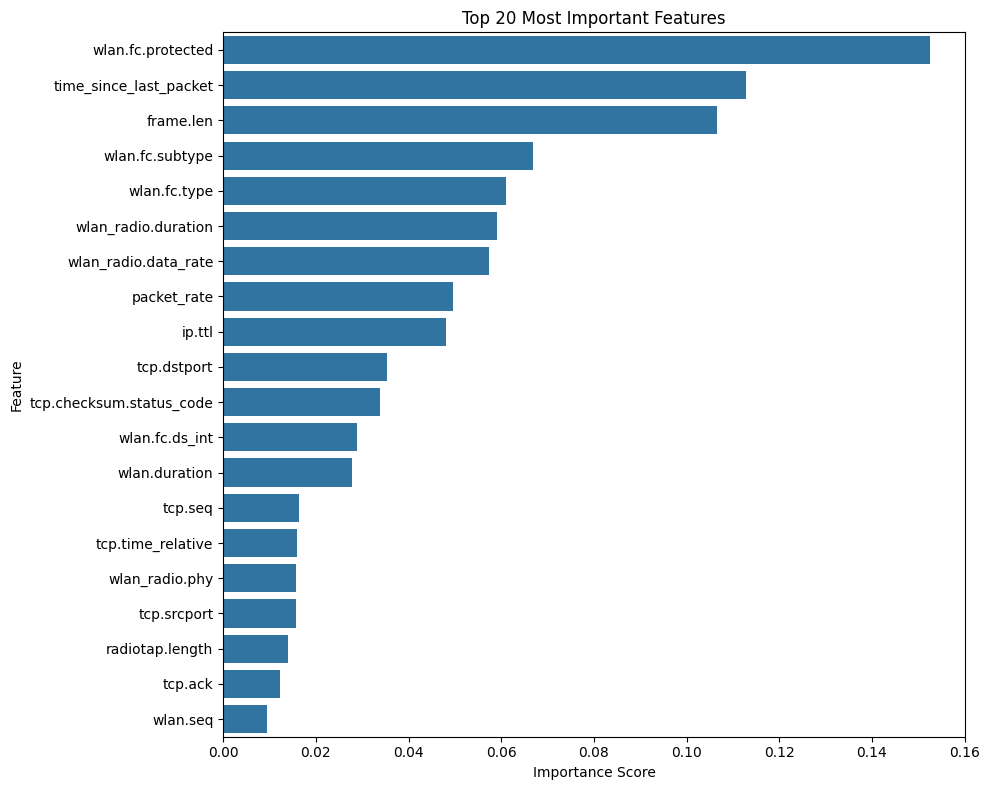

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 20 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()